In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Data augmentation for training
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# No augmentation for validation / test
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# Load datasets
train_dataset = datasets.ImageFolder(
    'train',
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    'val',
    transform=val_transforms
)

test_dataset = datasets.ImageFolder(
    'test',
    transform=val_transforms
)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print(f'Training samples: {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Training samples: 4000
Validation samples: 400
Test samples: 400


In [7]:

# Load pretrained ResNet18
model = models.resnet18(
    weights=models.ResNet18_Weights.IMAGENET1K_V1
)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer for binary classification
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Move to GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
model = model.to(device)

print(f"Using device: {device}")
print(
    f"Training only final layer with "
    f"{model.fc.in_features} output to 2"
)


Using device: cpu
Training only final layer with 512 output to 2


In [8]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

# Training tracking
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_acc = 0.0


In [9]:
num_epochs = 10

for epoch in range(num_epochs):
    # -----------------
    # Training phase
    # -----------------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # -----------------
    # Validation phase
    # -----------------
    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # -----------------
    # Update learning rate
    # -----------------
    scheduler.step(val_loss)

    # -----------------
    # Save best model
    # -----------------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Saved best model with val_acc: {val_acc:.2f}%")

    # -----------------
    # Print epoch statistics
    # -----------------
    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print()


Saved best model with val_acc: 98.25%
Epoch [1/10]
Train Loss: 0.2789, Train Acc: 88.75%
Val Loss: 0.0873, Val Acc: 98.25%

Epoch [2/10]
Train Loss: 0.1554, Train Acc: 94.03%
Val Loss: 0.0685, Val Acc: 98.25%

Saved best model with val_acc: 98.75%
Epoch [3/10]
Train Loss: 0.1360, Train Acc: 94.92%
Val Loss: 0.0490, Val Acc: 98.75%

Epoch [4/10]
Train Loss: 0.1213, Train Acc: 95.03%
Val Loss: 0.0447, Val Acc: 98.25%

Saved best model with val_acc: 99.50%
Epoch [5/10]
Train Loss: 0.1206, Train Acc: 94.83%
Val Loss: 0.0401, Val Acc: 99.50%

Epoch [6/10]
Train Loss: 0.1230, Train Acc: 94.70%
Val Loss: 0.0403, Val Acc: 99.25%

Epoch [7/10]
Train Loss: 0.1097, Train Acc: 95.60%
Val Loss: 0.0459, Val Acc: 98.00%

Epoch [8/10]
Train Loss: 0.1181, Train Acc: 95.20%
Val Loss: 0.0365, Val Acc: 99.50%

Epoch [9/10]
Train Loss: 0.1076, Train Acc: 95.97%
Val Loss: 0.0360, Val Acc: 99.50%

Epoch [10/10]
Train Loss: 0.1017, Train Acc: 95.90%
Val Loss: 0.0476, Val Acc: 98.25%



In [10]:
# Load best model
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")


Test Accuracy: 98.00%


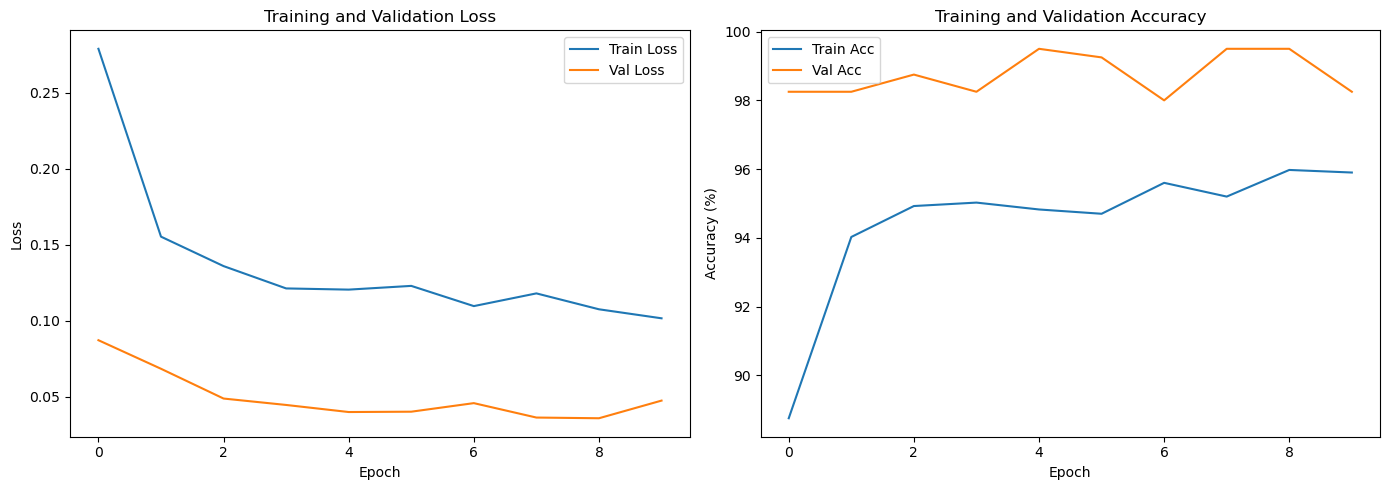

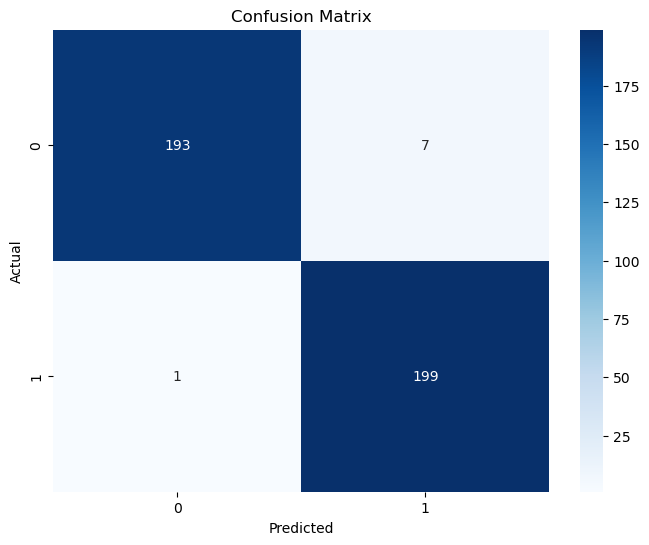

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------
# Plot training curves
# -----------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# Accuracy curves
ax2.plot(train_accs, label='Train Acc')
ax2.plot(val_accs, label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

# -----------------
# Confusion matrix
# -----------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()
